# Gym Member Churn — Classification 
Predict whether a gym member will **churn** (cancel their membership — i.e. leave the
service) using a **synthetic dataset generated by Claude** (6,000 members).

The data is created with *designed* churn drivers, so after training we can check
whether the models rediscover the ground-truth patterns.

**Pipeline:** generate data → EDA → train/test split → 3 models
(Logistic Regression, Random Forest, SVM) → GridSearchCV tuning →
accuracy / precision / recall / F1 / ROC → feature importance → interpretation.


## 1. Setup & imports

In [1]:
# If running in Google Colab, the standard scientific stack is preinstalled.
# Uncomment the next line only if a package is missing:
# !pip install scikit-learn pandas numpy matplotlib seaborn

import warnings
# Silence the sklearn FutureWarning about SVC(probability=True) (deprecated in 1.9).
# The code still runs correctly; this just keeps the output clean.
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## 2. Generate the synthetic dataset

We ask Claude to synthesize gym members with realistic, *designed* relationships:
month-to-month contracts, low tenure, few weekly visits, long distance to the gym,
no personal trainer and promo sign-ups all **increase** churn; long contracts,
frequent visits, group classes and extra spending **decrease** it.
A Gaussian noise term keeps the problem realistically hard (not trivially separable).

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def generate_gym_churn(n_rows=6000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    # --- raw features ---
    tenure = rng.integers(0, 73, n_rows)                        # months as a member
    contract_type = rng.choice(["Month-to-month", "6-month", "Annual"],
                               n_rows, p=[0.55, 0.25, 0.20])
    base_fee = np.select(
        [contract_type == "Month-to-month", contract_type == "6-month",
         contract_type == "Annual"],
        [rng.normal(55, 10, n_rows), rng.normal(48, 8, n_rows),
         rng.normal(42, 8, n_rows)])
    monthly_fee = np.clip(base_fee, 25, 90).round(2)

    avg_weekly_visits = np.clip(rng.normal(2.5, 1.3, n_rows), 0, 7).round(2)
    num_group_classes = rng.poisson(3, n_rows)                 # classes / month
    distance_km = np.clip(rng.gamma(2.0, 4.0, n_rows), 0.3, 30).round(1)
    extra_spending = np.clip(rng.gamma(1.5, 15, n_rows), 0, 200).round(2)
    age = rng.integers(18, 71, n_rows)
    personal_trainer = rng.choice(["Yes", "No"], n_rows, p=[0.3, 0.7])
    signup_promo = rng.choice(["Yes", "No"], n_rows, p=[0.4, 0.6])
    gender = rng.choice(["Female", "Male"], n_rows, p=[0.5, 0.5])
    total_paid = (np.maximum(tenure, 1) * monthly_fee
                  * rng.normal(1.0, 0.05, n_rows)).round(2)

    # --- designed churn model (ground-truth drivers) ---
    contract_effect = np.select(
        [contract_type == "Month-to-month", contract_type == "6-month",
         contract_type == "Annual"], [1.3, -0.2, -1.1])
    trainer_effect = np.where(personal_trainer == "No", 0.4, 0.0)
    promo_effect = np.where(signup_promo == "Yes", 0.35, 0.0)

    logit = (-0.08 + contract_effect - 0.030*tenure
             - 0.55*avg_weekly_visits + 0.05*distance_km
             + 0.010*(monthly_fee - 45) - 0.04*num_group_classes
             - 0.004*extra_spending + trainer_effect + promo_effect
             + rng.normal(0, 0.35, n_rows))
    churn = rng.binomial(1, sigmoid(logit))

    return pd.DataFrame({
        "tenure": tenure, "monthly_fee": monthly_fee, "total_paid": total_paid,
        "avg_weekly_visits": avg_weekly_visits, "num_group_classes": num_group_classes,
        "distance_km": distance_km, "extra_spending": extra_spending, "age": age,
        "contract_type": contract_type, "personal_trainer": personal_trainer,
        "signup_promo": signup_promo, "gender": gender, "Churn": churn.astype(int),
    })

df = generate_gym_churn()
print("Shape:", df.shape, "| churn rate:", round(df["Churn"].mean(), 3))
df.head()

Shape: (6000, 13) | churn rate: 0.274


,tenure,monthly_fee,total_paid,avg_weekly_visits,num_group_classes,distance_km,extra_spending,age,contract_type,personal_trainer,signup_promo,gender,Churn
0,6,38.75,235.78,1.58,3,3.2,55.09,55,Annual,Yes,No,Male,0
1,56,51.79,2874.15,3.90,0,3.8,44.10,54,6-month,No,No,Male,0
2,47,65.13,3336.50,3.97,3,10.8,23.85,65,Month-to-month,Yes,No,Female,0
3,32,47.53,1471.44,1.92,2,6.9,5.58,54,6-month,Yes,Yes,Male,0
4,31,56.66,1633.13,5.19,2,1.5,5.85,49,Month-to-month,Yes,Yes,Male,0


## 3. Exploratory data analysis (EDA)

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure,6000.0,NaN,NaN,NaN,35.916333,21.053255,0.0,18.0,36.0,54.0,72.0
monthly_fee,6000.0,NaN,NaN,NaN,50.807012,10.388224,25.0,43.53,50.4,57.675,90.0
total_paid,6000.0,NaN,NaN,NaN,1823.071158,1150.885191,28.84,840.7575,1749.715,2661.84,5820.0
avg_weekly_visits,6000.0,NaN,NaN,NaN,2.5207,1.283617,0.0,1.62,2.51,3.39,7.0
num_group_classes,6000.0,NaN,NaN,NaN,3.011,1.728307,0.0,2.0,3.0,4.0,11.0
distance_km,6000.0,NaN,NaN,NaN,8.00845,5.642687,0.3,3.8,6.7,10.8,30.0
extra_spending,6000.0,NaN,NaN,NaN,22.536237,18.82675,0.1,9.02,17.42,30.6625,174.22
age,6000.0,NaN,NaN,NaN,43.745167,15.237889,18.0,31.0,44.0,57.0,70.0
contract_type,6000,3,Month-to-month,3321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
personal_trainer,6000,2,No,4155,NaN,NaN,NaN,NaN,NaN,NaN,NaN


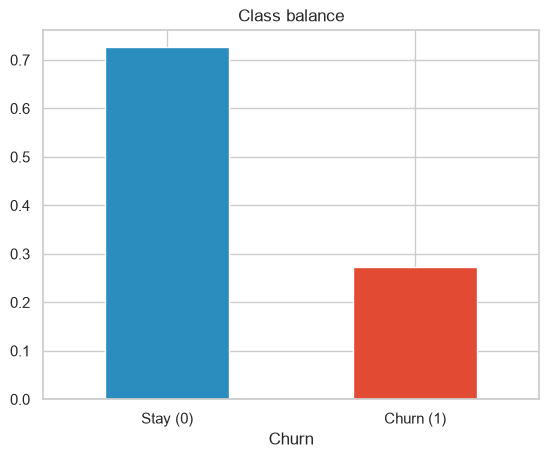

In [4]:
# Target balance
ax = df["Churn"].value_counts(normalize=True).sort_index().plot(
    kind="bar", color=["#2b8cbe", "#e34a33"])
ax.set_xticklabels(["Stay (0)", "Churn (1)"], rotation=0)
ax.set_title("Class balance")
plt.show()

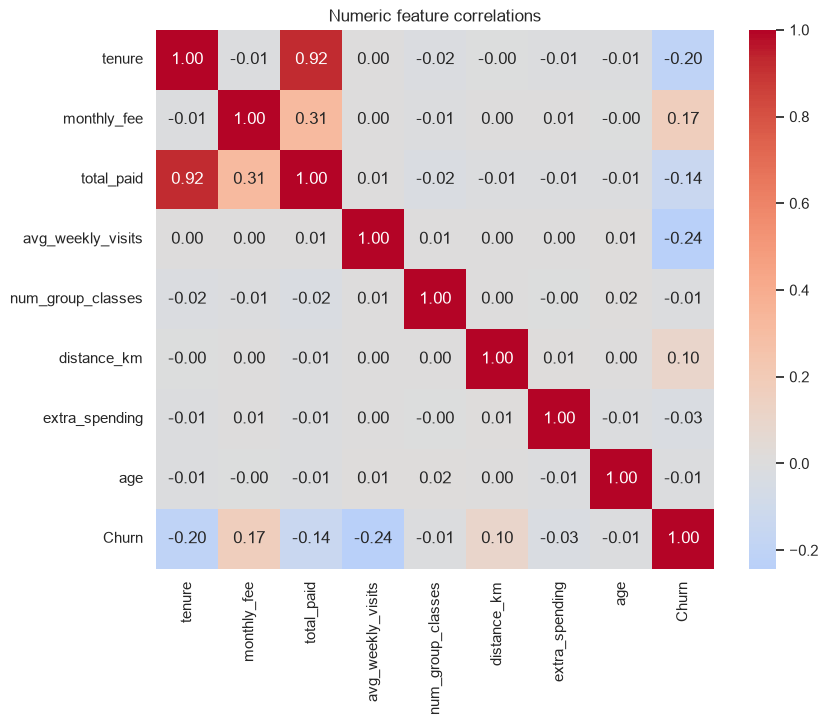

In [5]:
# Correlation heatmap (numeric features + target)
num = df.select_dtypes("number")
plt.figure(figsize=(9, 7))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.show()

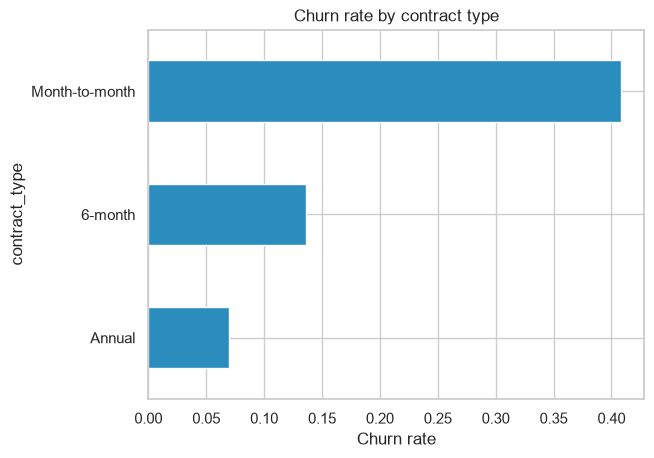

In [6]:
# Churn rate by contract type — the strongest designed driver
(df.groupby("contract_type")["Churn"].mean().sort_values()
   .plot(kind="barh", color="#2b8cbe", title="Churn rate by contract type"))
plt.xlabel("Churn rate")
plt.show()

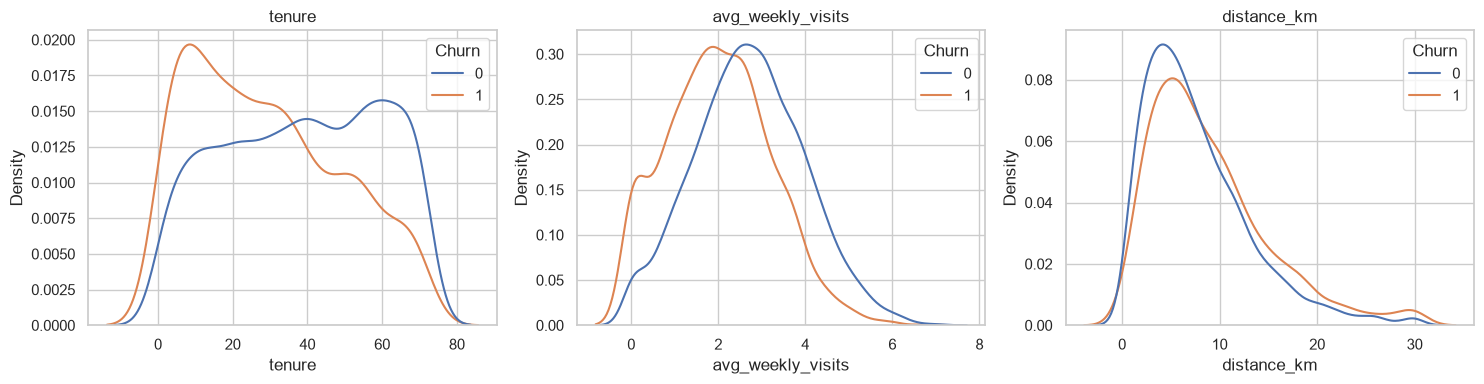

In [7]:
# How key numeric features differ between churned and retained members
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "avg_weekly_visits", "distance_km"]):
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**EDA takeaways:** month-to-month members churn far more than annual ones;
churned members have shorter tenure, fewer weekly visits, and live farther from the gym —
matching the patterns we designed into the data.

## 4. Train/test split

In [8]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (4800, 12) | Test: (1200, 12)


## 5–6. Models + hyperparameter tuning

Each model sits in a `Pipeline`: a `ColumnTransformer` scales the numeric columns and
one-hot encodes the categorical ones, then the classifier runs. We tune with
`GridSearchCV` (5-fold CV, scoring = ROC-AUC).

In [9]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

configs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 1, 10]}),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 6, 10],
         "clf__min_samples_split": [2, 5]}),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1]}),
}

results = {}
for name, (est, grid_params) in configs.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("clf", est)])
    grid = GridSearchCV(pipe, grid_params, cv=5, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    y_score = get_scores(best, X_test)
    results[name] = {
        "estimator": best, "best_params": grid.best_params_,
        "y_pred": y_pred, "y_score": y_score,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
    }
    print(f"{name}: best={grid.best_params_}")

Logistic Regression: best={'clf__C': 10}
Random Forest: best={'clf__max_depth': 6, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
SVM (RBF): best={'clf__C': 1, 'clf__gamma': 0.01}


## 7. Evaluation

In [10]:
summary = pd.DataFrame({
    n: {k: r[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}
    for n, r in results.items()}).T.round(3)
summary

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.771,0.621,0.422,0.503,0.813
Random Forest,0.765,0.633,0.340,0.443,0.809
SVM (RBF),0.762,0.629,0.319,0.423,0.811


Best model by ROC-AUC: Logistic Regression 

              precision    recall  f1-score   support

        Stay       0.81      0.90      0.85       871
       Churn       0.62      0.42      0.50       329

    accuracy                           0.77      1200
   macro avg       0.71      0.66      0.68      1200
weighted avg       0.75      0.77      0.76      1200



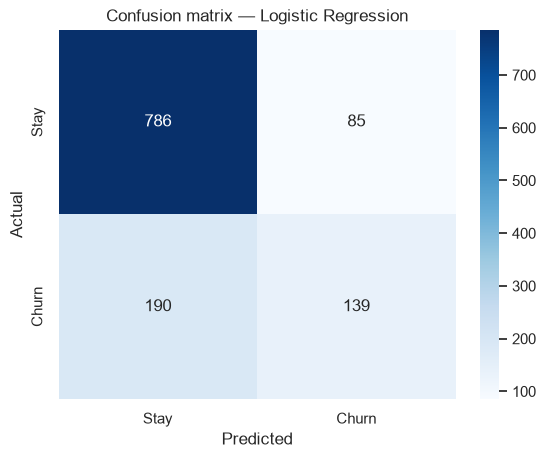

In [11]:
# Detailed report + confusion matrix for the best model (by ROC-AUC)
best_name = max(results, key=lambda n: results[n]["roc_auc"])
print("Best model by ROC-AUC:", best_name, "\n")
print(classification_report(y_test, results[best_name]["y_pred"],
                            target_names=["Stay", "Churn"]))
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
plt.title(f"Confusion matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

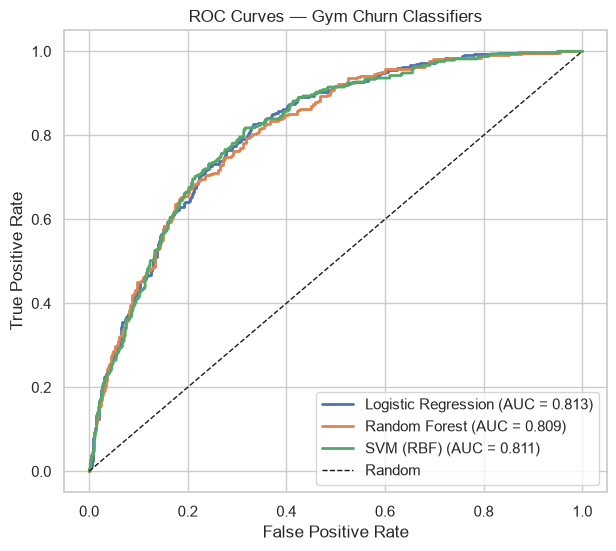

In [12]:
# ROC curves for all models
plt.figure(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_score"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Gym Churn Classifiers")
plt.legend(loc="lower right")
plt.show()

## 8. Feature importance

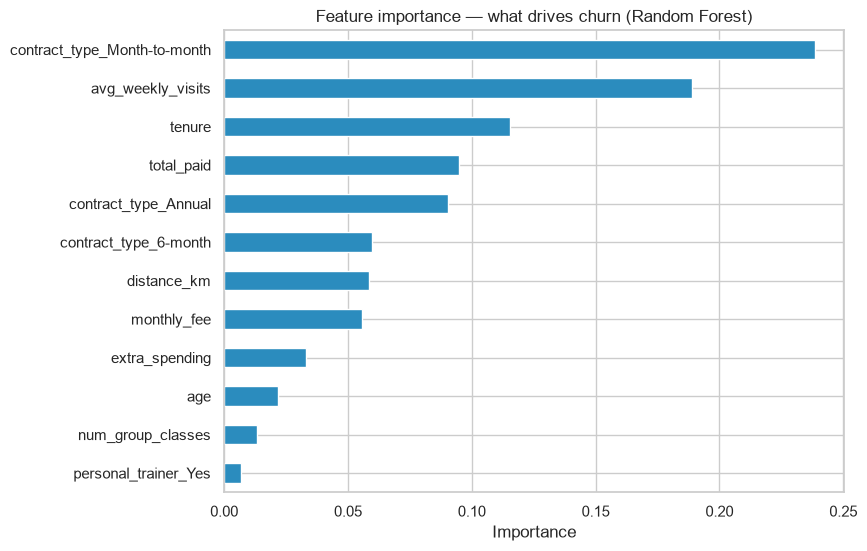

contract_type_Month-to-month    0.238
avg_weekly_visits               0.189
tenure                          0.116
total_paid                      0.095
contract_type_Annual            0.090
contract_type_6-month           0.060
distance_km                     0.058
monthly_fee                     0.056
dtype: float64

In [13]:
# Random Forest importances (expanded feature names after one-hot encoding)
rf = results["Random Forest"]["estimator"]
feat_names = [n.split("__", 1)[-1] for n in rf.named_steps["prep"].get_feature_names_out()]
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=feat_names)
imp.sort_values().tail(12).plot(kind="barh", figsize=(8, 6), color="#2b8cbe")
plt.title("Feature importance — what drives churn (Random Forest)")
plt.xlabel("Importance")
plt.show()
imp.sort_values(ascending=False).head(8).round(3)

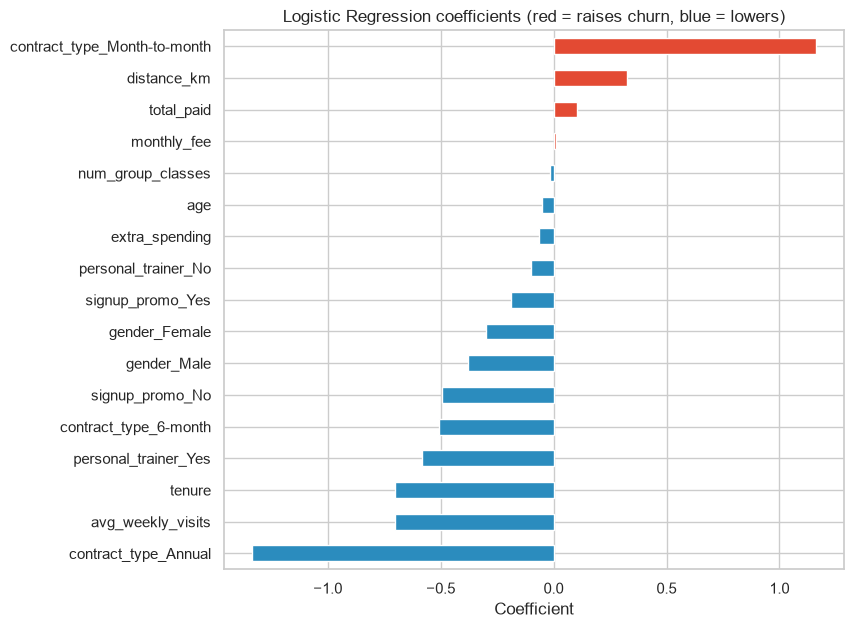

In [14]:
# Logistic Regression coefficients (sign = direction of effect on churn)
lr = results["Logistic Regression"]["estimator"]
lr_names = [n.split("__", 1)[-1] for n in lr.named_steps["prep"].get_feature_names_out()]
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=lr_names).sort_values()
coef.plot(kind="barh", figsize=(8, 7),
          color=(coef > 0).map({True: "#e34a33", False: "#2b8cbe"}))
plt.title("Logistic Regression coefficients (red = raises churn, blue = lowers)")
plt.xlabel("Coefficient")
plt.show()

## 9. Interpretation & business actions

**Top churn drivers** (both models agree, and they match the designed ground truth):

- **Contract type** — month-to-month members churn far more; annual contracts churn least.
- **Average weekly visits** — disengaged members (few visits) are the biggest flight risk.
- **Tenure** — newer members churn more; loyalty builds stickiness.
- **Distance to gym** — members who live far away churn more.
- **Monthly fee, no personal trainer, promo sign-ups** — all nudge churn upward.

**Recommended actions**

1. **Push longer plans** with incentives and invest in **onboarding** in the first months
   (low tenure + month-to-month is the highest-risk combination).
2. **Watch weekly visits** — when a member's attendance drops, trigger nudges / reactivation
   campaigns before they cancel.
3. **Support far-away & promo members** with retention offers, and encourage group classes /
   personal training, which keep members engaged.

Because we designed the data, we can confirm the models recovered the true drivers — a good
sanity check that the pipeline works before trusting it on real data.